In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [7]:
df = pd.read_csv("http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv")

In [16]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120108 entries, ak11155107 to ak11453389
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       120108 non-null  datetime64[ns]     
 1   latitude   120108 non-null  float64            
 2   longitude  120108 non-null  float64            
 3   depth      120107 non-null  float64            
 4   mag        120065 non-null  float64            
 5   magType    120065 non-null  object             
 6   nst        59688 non-null   float64            
 7   gap        94935 non-null   float64            
 8   dmin       85682 non-null   float64            
 9   rms        119716 non-null  float64            
 10  net        120108 non-null  object             
 11  updated    120108 non-null  datetime64[ns, UTC]
 12  place      120108 non-null  object             
 13  type       120108 non-null  object             
dtypes: datetime64[ns, UTC](1), d

In [17]:
df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'updated', 'place', 'type'], dtype='object')

In [18]:
url = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"

df = pd.read_csv(
    url,
    parse_dates=['time', 'updated'],   
    index_col='id'                     
)

In [19]:
df.describe()

,time,latitude,longitude,depth,mag,nst,gap,dmin,rms
count,120108,120108.000000,120108.000000,120107.000000,120065.000000,59688.000000,94935.000000,85682.000000,119716.000000
mean,2014-07-05 09:10:37.116720128,38.399579,-99.961402,28.375029,1.793958,17.878284,124.048978,0.893198,0.358174
min,2014-01-01 00:01:16.610000,-73.462000,-179.998900,-9.900000,-0.970000,0.000000,9.000000,0.000000,0.000000
25%,2014-04-08 03:43:10.768999936,34.228917,-147.742025,4.100000,0.820000,8.000000,74.000000,0.020760,0.070000
50%,2014-07-07 10:44:06.035000064,38.805300,-120.832000,9.200000,1.400000,14.000000,107.000000,0.073670,0.200000
75%,2014-09-30 23:36:40.595000064,53.889500,-116.068100,22.880000,2.400000,22.000000,155.000000,0.447000,0.590000
max,2014-12-31 23:54:33.900000,86.651400,179.998000,697.360000,8.200000,365.000000,356.400000,64.498000,8.460000
std,NaN,21.938258,82.996858,62.215416,1.343466,14.911369,68.518595,2.903966,0.364046


In [20]:
top20 = df.nlargest(20, 'mag')
top20

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
usc000nzvd,2014-04-01 23:46:47.260,-19.6097,-70.7691,25.00,8.2,mww,NaN,23.0,0.609,0.66,us,2015-07-30 16:24:51.223000+00:00,"94km NW of Iquique, Chile",earthquake
usc000rki5,2014-06-23 20:53:09.700,51.8486,178.7352,109.00,7.9,mww,NaN,22.0,0.133,0.71,us,2015-04-18 21:54:08.699000+00:00,"19km SE of Little Sitkin Island, Alaska",earthquake
usc000p27i,2014-04-03 02:43:13.110,-20.5709,-70.4931,22.40,7.7,mww,NaN,44.0,1.029,0.82,us,2015-06-06 07:31:05.755000+00:00,"53km SW of Iquique, Chile",earthquake
usc000phx5,2014-04-12 20:14:39.300,-11.2701,162.1481,22.56,7.6,mww,NaN,13.0,2.828,0.71,us,2015-04-18 21:54:27.398000+00:00,"93km SSE of Kirakira, Solomon Islands",earthquake
usb000pr89,2014-04-19 13:28:00.810,-6.7547,155.0241,43.37,7.5,mww,NaN,16.0,3.820,1.25,us,2015-04-18 21:54:18.633000+00:00,"70km SW of Panguna, Papua New Guinea",earthquake
usc000piqj,2014-04-13 12:36:19.230,-11.4633,162.0511,39.00,7.4,mww,NaN,17.0,2.885,1.00,us,2015-08-13 19:29:13.018000+00:00,"112km S of Kirakira, Solomon Islands",earthquake
usb000slwn,2014-10-14 03:51:34.460,12.5262,-88.1225,40.00,7.3,mww,NaN,18.0,1.078,0.70,us,2015-08-13 19:35:02.679000+00:00,"74km S of Intipuca, El Salvador",earthquake
usb000pq41,2014-04-18 14:27:24.920,17.3970,-100.9723,24.00,7.2,mww,NaN,46.0,2.250,1.20,us,2015-08-13 19:30:39.599000+00:00,"33km ESE of Petatlan, Mexico",earthquake
usc000pft9,2014-04-11 07:07:23.130,-6.5858,155.0485,60.53,7.1,mww,NaN,21.0,3.729,0.88,us,2014-07-01 02:37:56+00:00,"56km WSW of Panguna, Papua New Guinea",earthquake


In [21]:
df['mag'].nlargest(20)

id
usc000nzvd    8.2
usc000rki5    7.9
usc000p27i    7.7
usc000phx5    7.6
usb000pr89    7.5
usc000piqj    7.4
usb000slwn    7.3
usb000pq41    7.2
usc000pft9    7.1
usc000sxh8    7.1
usc000stdc    7.1
usb000sk6k    7.0
usc000mnvj    6.9
usc000nzwm    6.9
usb000r2hc    6.9
usc000rngj    6.9
usc000rkg5    6.9
usb000ruzk    6.9
usc000rr6a    6.9
usb000rzki    6.9
Name: mag, dtype: float64

In [22]:
df['place'].head(20)

id
ak11155107        26km S of Redoubt Volcano, Alaska
nn00436847                  32km S of Alamo, Nevada
ak11151142         12km NNW of North Nenana, Alaska
ak11151135               22km S of Cantwell, Alaska
ci37171541             10km WNW of Progreso, Mexico
ci11419722                 3km N of Tijuana, Mexico
ci11419714    11km N of Borrego Springs, California
ak11151127            61km NNW of Talkeetna, Alaska
ak11151125               48km NNE of Kodiak, Alaska
nc72153361           3km E of Livermore, California
usc000mqlp     115km ESE of Taron, Papua New Guinea
ak11155101              71km SE of Whittier, Alaska
nc72153351         0km N of The Geysers, California
nc72153356     4km WSW of Mammoth Lakes, California
usc000mqln     120km N of Raoul Island, New Zealand
nm020414a             6km SSW of Lilbourn, Missouri
usc000mqls                South of the Fiji Islands
ci11419698           27km ESE of Julian, California
ci11419706          52km S of Lone Pine, California
ak1115110

In [24]:
top20[['place', 'mag']]

,place,mag
id,,
usc000nzvd,"94km NW of Iquique, Chile",8.2
usc000rki5,"19km SE of Little Sitkin Island, Alaska",7.9
usc000p27i,"53km SW of Iquique, Chile",7.7
usc000phx5,"93km SSE of Kirakira, Solomon Islands",7.6
usb000pr89,"70km SW of Panguna, Papua New Guinea",7.5
usc000piqj,"112km S of Kirakira, Solomon Islands",7.4
usb000slwn,"74km S of Intipuca, El Salvador",7.3
usb000pq41,"33km ESE of Petatlan, Mexico",7.2
usc000pft9,"56km WSW of Panguna, Papua New Guinea",7.1


In [26]:
df['country'] = df['place'].str.split(',').str[-1].str.strip()

In [27]:
df[['place', 'country']].head(5)

,place,country
id,,
ak11155107,"26km S of Redoubt Volcano, Alaska",Alaska
nn00436847,"32km S of Alamo, Nevada",Nevada
ak11151142,"12km NNW of North Nenana, Alaska",Alaska
ak11151135,"22km S of Cantwell, Alaska",Alaska
ci37171541,"10km WNW of Progreso, Mexico",Mexico


In [28]:
df['country'].unique()

array(['Alaska', 'Nevada', 'Mexico', 'California', 'Papua New Guinea',
       'New Zealand', 'Missouri', 'South of the Fiji Islands', 'Montana',
       'British Virgin Islands', 'Washington', 'Oregon', 'Canada', 'Fiji',
       'Wyoming', 'Antarctica', 'Chile', 'Utah', 'Indonesia',
       'Solomon Islands', 'Micronesia', 'Oklahoma', 'Hawaii', 'Russia',
       'Arizona', 'Philippines', 'Bolivia', 'Greece', 'Japan',
       'Puerto Rico', 'Iran', 'Tonga', 'Wallis and Futuna', 'Colorado',
       'Guam', 'CA', 'Carlsberg Ridge', 'Idaho', 'Pakistan',
       'Off the west coast of northern Sumatra', 'Burma', 'China', 'Peru',
       'Off the east coast of the North Island of New Zealand',
       'Costa Rica', 'Reykjanes Ridge', 'East Timor',
       'Central East Pacific Rise', 'Mid-Indian Ridge', 'Japan region',
       'Northern Mariana Islands', 'El Salvador', 'Samoa',
       'Northern Mid-Atlantic Ridge', 'Taiwan', 'Arkansas',
       'South Sandwich Islands', 'Colombia', 'Dominican Republic',

In [29]:
mag4 = df[df['mag'] >= 4]

In [30]:
mag4.head()
mag4.shape

(17547, 15)

In [31]:
country_counts = mag4['country'].value_counts()
country_counts.head()

country
Indonesia           2116
Papua New Guinea    1354
Japan               1150
Chile               1124
New Zealand          758
Name: count, dtype: int64

In [32]:
top5 = country_counts.head(5)
top5

country
Indonesia           2116
Papua New Guinea    1354
Japan               1150
Chile               1124
New Zealand          758
Name: count, dtype: int64

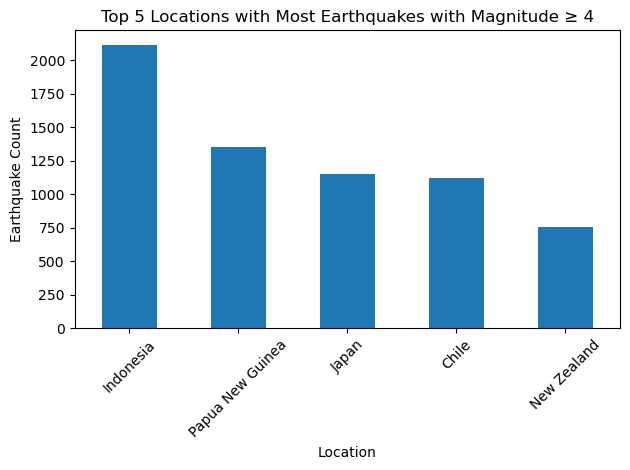

In [33]:
top5.plot(kind='bar')

plt.xlabel('Location')
plt.ylabel('Earthquake Count')
plt.title('Top 5 Locations with Most Earthquakes with Magnitude ≥ 4')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

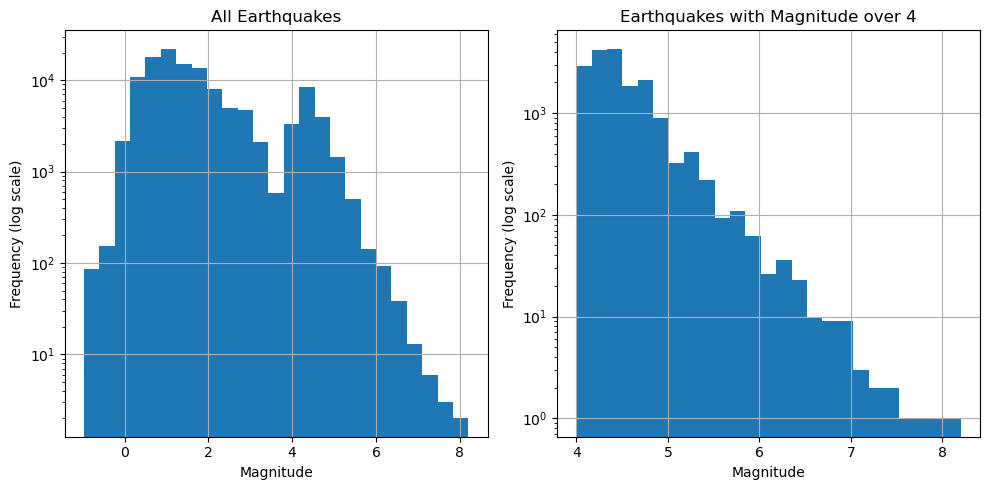

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

df['mag'].hist(ax=axes[0], bins=25, log=True)
axes[0].set_title('All Earthquakes')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Frequency (log scale)')

mag4['mag'].hist(ax=axes[1], bins=25, log=True)
axes[1].set_title('Earthquakes with Magnitude over 4')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Frequency (log scale)')

plt.tight_layout()
plt.show()

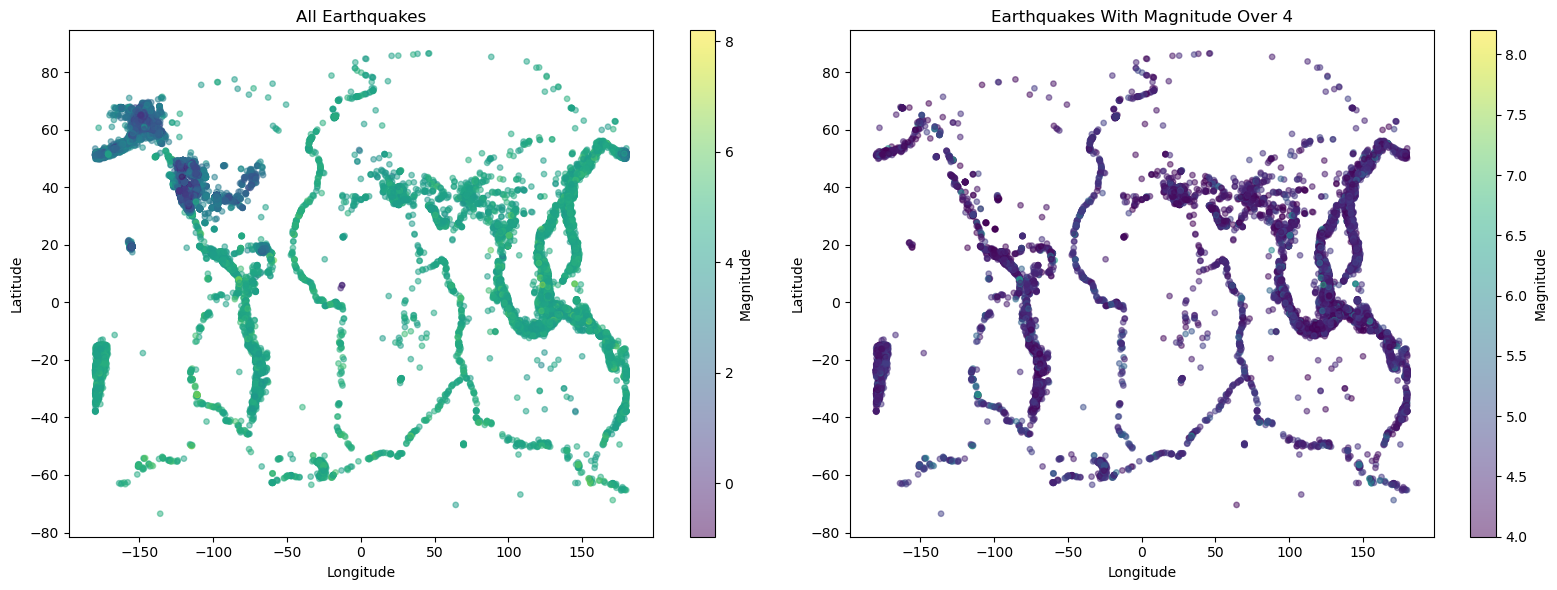

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    df['longitude'],
    df['latitude'],
    c=df['mag'],        
    s=15,               
    alpha=0.5           
)

axes[0].set_title('All Earthquakes')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

plt.colorbar(scatter1, ax=axes[0], label='Magnitude')

scatter2 = axes[1].scatter(
    mag4['longitude'],
    mag4['latitude'],
    c=mag4['mag'],
    s=15,
    alpha=0.5
)

axes[1].set_title('Earthquakes With Magnitude Over 4')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.colorbar(scatter2, ax=axes[1], label='Magnitude')


plt.tight_layout()
plt.show()